In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import json

# Load dataset
DATASET_PATH = Path("./herbal_domain_dataset")
source_labels = pd.read_csv(DATASET_PATH / "source" / "labels.csv")
test_labels = pd.read_csv(DATASET_PATH / "test" / "test_labels.csv")

print("EDA: HERBAL PLANT DATASET")
print(f"\nSource images: {len(source_labels)}")
print(f"Test images: {len(test_labels)}")
print(f"Target images: {len(list((DATASET_PATH / 'target' / 'images').glob('*.jpg')))}")

EDA: HERBAL PLANT DATASET

Source images: 514
Test images: 104
Target images: 524


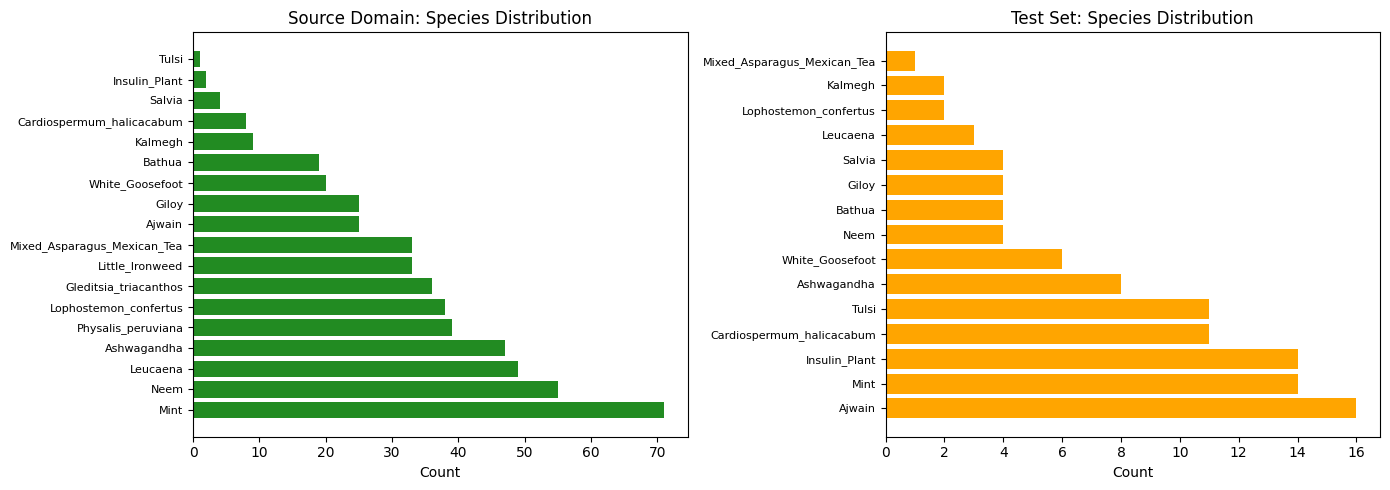


Most common: Mint (71 images)
Least common: Tulsi (1 images)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source distribution
species_counts = source_labels['species'].value_counts()
axes[0].barh(range(len(species_counts)), species_counts.values, color='forestgreen')
axes[0].set_yticks(range(len(species_counts)))
axes[0].set_yticklabels(species_counts.index, fontsize=8)
axes[0].set_xlabel('Count')
axes[0].set_title('Source Domain: Species Distribution')

# Test distribution
test_counts = test_labels['species'].value_counts()
axes[1].barh(range(len(test_counts)), test_counts.values, color='orange')
axes[1].set_yticks(range(len(test_counts)))
axes[1].set_yticklabels(test_counts.index, fontsize=8)
axes[1].set_xlabel('Count')
axes[1].set_title('Test Set: Species Distribution')

plt.tight_layout()
plt.show()

print(f"\nMost common: {species_counts.index[0]} ({species_counts.values[0]} images)")
print(f"Least common: {species_counts.index[-1]} ({species_counts.values[-1]} images)")

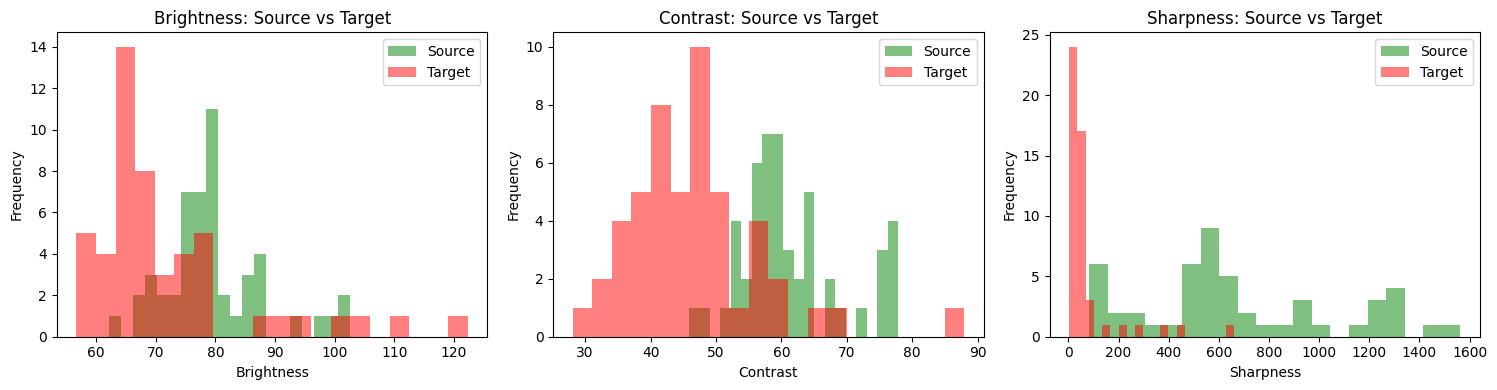


Average brightness - Source: 79.6 | Target: 72.0
Average contrast - Source: 61.3 | Target: 46.7
Average sharpness - Source: 666.3 | Target: 76.2


In [4]:
def get_img_stats(img_path):
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return {
        'brightness': np.mean(gray),
        'contrast': np.std(gray),
        'sharpness': cv2.Laplacian(gray, cv2.CV_64F).var()
    }

# Sample 50 images from source and target
source_path = DATASET_PATH / "source" / "images"
target_path = DATASET_PATH / "target" / "images"

source_samples = list(source_path.glob("*.jpg"))[:50]
target_samples = list(target_path.glob("*.jpg"))[:50]

source_stats = [get_img_stats(p) for p in source_samples]
target_stats = [get_img_stats(p) for p in target_samples]

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['brightness', 'contrast', 'sharpness']
titles = ['Brightness', 'Contrast', 'Sharpness']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    s_vals = [s[metric] for s in source_stats]
    t_vals = [t[metric] for t in target_stats]
    
    axes[i].hist(s_vals, bins=20, alpha=0.5, label='Source', color='green')
    axes[i].hist(t_vals, bins=20, alpha=0.5, label='Target', color='red')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].set_title(f'{title}: Source vs Target')

plt.tight_layout()
plt.show()

print(f"\nAverage brightness - Source: {np.mean([s['brightness'] for s in source_stats]):.1f} | Target: {np.mean([t['brightness'] for t in target_stats]):.1f}")
print(f"Average contrast - Source: {np.mean([s['contrast'] for s in source_stats]):.1f} | Target: {np.mean([t['contrast'] for t in target_stats]):.1f}")
print(f"Average sharpness - Source: {np.mean([s['sharpness'] for s in source_stats]):.1f} | Target: {np.mean([t['sharpness'] for t in target_stats]):.1f}")

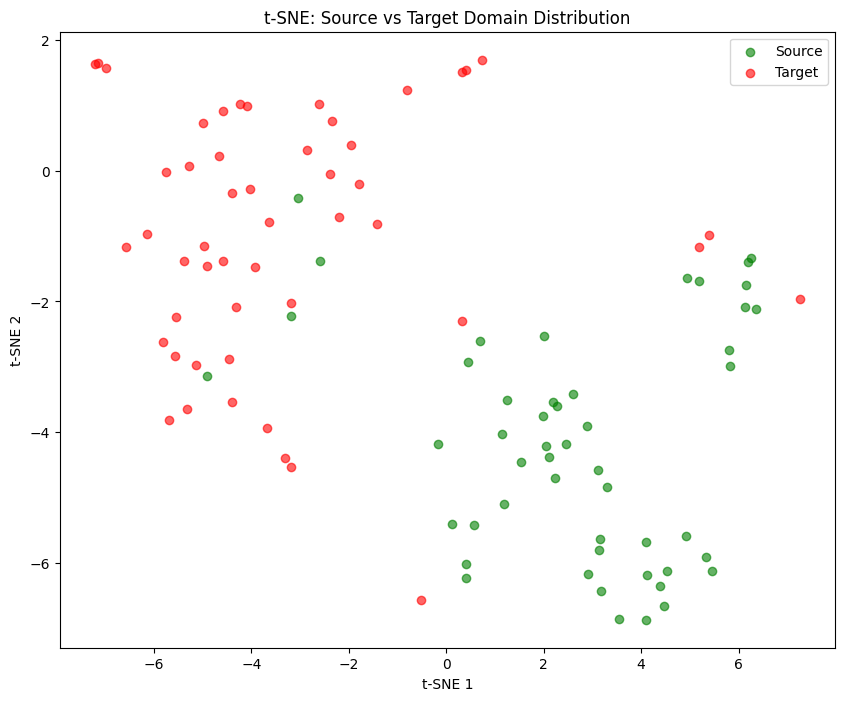


 Clear domain gap visible - Good for domain adaptation!


In [5]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Extract features using simple statistics
def extract_features(img_path):
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    return [
        np.mean(gray), np.std(gray), cv2.Laplacian(gray, cv2.CV_64F).var(),
        np.mean(hsv[:,:,1]), np.std(hsv[:,:,1]), np.mean(hsv[:,:,2]),
        np.percentile(gray, 25), np.percentile(gray, 75)
    ]

# Sample features
source_feats = [extract_features(p) for p in source_samples]
target_feats = [extract_features(p) for p in target_samples]

# Combine and reduce
X = np.vstack([source_feats, target_feats])
y = ['Source']*len(source_feats) + ['Target']*len(target_feats)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 8))
colors = {'Source': 'green', 'Target': 'red'}
for domain in ['Source', 'Target']:
    mask = np.array(y) == domain
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[domain], label=domain, alpha=0.6)

plt.title('t-SNE: Source vs Target Domain Distribution')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.show()

print("\n Clear domain gap visible - Good for domain adaptation!")